# Análisis — Media de pernoctaciones por comunidad autónoma y por ciudad

Encuesta de Ocupación Hotelera (EOH) del INE — año de referencia **2025**.

Este notebook parte del fichero generado por el proceso de limpieza y transformación:

```text
Data/clean_dataset_INE_EOH_20_07_2026.csv
```

## Pregunta de negocio

¿Es necesario ajustar la oferta al perfil del viajero y a la demanda de pernoctaciones
en las ciudades donde la plataforma está presente, considerando las cifras oficiales de
procedencia, meses de visita y media de pernoctaciones por comunidad autónoma?

Este notebook responde a la parte de **media de pernoctaciones** (estancia media):
cuántas noches permanece de media un viajero.

## Estructura

Sigue el patrón del bloque 3.3 de la presentación: primero la cifra **por mercado**, y
después el **zoom sobre el origen** del viajero nacional.

1. Estancia media por mercado, nacional vs. extranjero (2025).
2. Zoom: estancia media según la comunidad autónoma de origen del viajero nacional.

El **destino se mantiene siempre en los 8 mercados** y no se agrega a nivel de comunidad
autónoma. La comunidad autónoma aparece únicamente como **origen** del viajero nacional
dentro de cada mercado. Distinguir ambos usos es imprescindible: una misma comunidad
puede ser a la vez destino y origen, y confundirlos cambiaría por completo la lectura.

## Definición utilizada

La estancia media se calcula siempre como un **cociente de totales**:

```text
estancia media = total de pernoctaciones / total de viajeros
```

No se utiliza la media simple de los cocientes mensuales: cada mes tiene un volumen de
viajeros distinto, y promediar cocientes daría el mismo peso a agosto que a enero.

## Niveles geográficos de los mercados

Los 8 mercados no comparten un mismo nivel territorial en la EOH:

| Nivel | Tabla | Significado | Mercados |
|---|---|---|---|
| Punto turístico | 2078 | Municipio concreto | Barcelona, Madrid, València, Málaga, Sevilla |
| Zona turística | 2039 | Conjunto de municipios o isla | Girona, Mallorca, Menorca |

Un **punto turístico** es un municipio con concentración significativa de oferta
turística. Una **zona turística** es un conjunto de municipios con afluencia turística
específica. Por eso Mallorca y Menorca son islas completas y Girona se corresponde con
la zona turística de la Costa Brava, no con el municipio.

## Alcance y limitaciones

- La EOH mide **establecimientos hoteleros**, no apartamentos turísticos. Se utiliza como
  referencia oficial de la demanda del sector, no como fuente directamente equivalente.
- Los datos de junio de 2025 y posteriores son **provisionales** y pueden revisarse.
- Las celdas marcadas por el INE como sin dato publicado **no son ceros** y se excluyen
  del cálculo en lugar de sumarse como cero.
- La estancia media por origen es una **estimación ponderada**, no un dato directo
  publicado en una única tabla (ver apartado 6).
- Los resultados se interpretan como patrones y asociaciones, nunca como relaciones
  causales.

## 1. Librerías y localización del proyecto

In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

NOMBRE_DATASET = "clean_dataset_INE_EOH_20_07_2026.csv"


def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """Localiza Equip_34 desde el directorio actual o sus padres."""
    actual = Path.cwd().resolve()

    for carpeta in [actual, *actual.parents]:
        if carpeta.name == nombre_carpeta:
            return carpeta

        candidata = carpeta / nombre_carpeta
        if (candidata / "Data").is_dir() and (candidata / "Scripts").is_dir():
            return candidata

    raise FileNotFoundError(
        f"No se encontró la carpeta {nombre_carpeta}. "
        "Abre el repositorio ProjecteData o ejecuta el notebook desde Equip_34."
    )


RAIZ_PROYECTO = encontrar_raiz_proyecto()
RUTA_DATASET = RAIZ_PROYECTO / "Data" / NOMBRE_DATASET

if not RUTA_DATASET.exists():
    raise FileNotFoundError(
        f"No se encontró {NOMBRE_DATASET}. "
        "Ejecuta antes el notebook de limpieza y el de transformación."
    )

print(f"Dataset localizado: {NOMBRE_DATASET}")

Dataset localizado: clean_dataset_INE_EOH_20_07_2026.csv


## 2. Parámetros y estilo visual

Los colores y el orden de los mercados se fijan aquí una sola vez para que todos los
gráficos del notebook sean coherentes entre sí y con el resto de la presentación.

El **orden de los mercados** es de mayor a menor peso del turismo extranjero en 2025.
Es el mismo orden en todas las secciones, de modo que las diapositivas puedan compararse
sin releer las etiquetas.

In [33]:
# Año de referencia del análisis
ANIO_REFERENCIA = 2025

# Orden único de mercados: de mayor a menor peso del turismo extranjero (2025)
ORDEN_MERCADOS = [
    "Mallorca", "Barcelona", "Menorca", "Girona",
    "Sevilla", "Málaga", "Madrid", "Valencia",
]

# Paleta corporativa: mismo criterio de color en toda la presentación
COLOR_NACIONAL = "#11949D"
COLOR_EXTRANJERO = "#002F5D"
COLOR_ACENTO = "#FECB48"
COLOR_TEXTO = "#002F5D"

ETIQUETA_NACIONAL = "Nacional (residentes en España)"
ETIQUETA_EXTRANJERO = "Extranjero"

COLOR_POR_CATEGORIA = {
    "Residentes en España": COLOR_NACIONAL,
    "Residentes en el Extranjero": COLOR_EXTRANJERO,
}

plt.rcParams["font.size"] = 11
plt.rcParams["axes.edgecolor"] = "#D9D9D9"
plt.rcParams["axes.labelcolor"] = COLOR_TEXTO
plt.rcParams["text.color"] = COLOR_TEXTO
plt.rcParams["xtick.color"] = COLOR_TEXTO
plt.rcParams["ytick.color"] = COLOR_TEXTO

def formato_noches(valor, _):
    """Añade la unidad al eje para evitar leerlo como un volumen."""
    if valor == 0:
        return "0"
    if valor == 1:
        return "1 noche"
    if float(valor).is_integer():
        return f"{valor:.0f} noches"
    return f"{valor:.1f}"


print("Parámetros de estilo definidos.")

Parámetros de estilo definidos.


## 3. Carga del dataset

`tabla`, `codigo_ine` y `periodo` se leen como texto de forma explícita: son códigos
identificadores, no cantidades. Si se leyeran como números, `2074` dejaría de coincidir
con el texto `"2074"` al filtrar y los códigos perderían los ceros iniciales.

In [34]:
df = pd.read_csv(
    RUTA_DATASET,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    dtype={
        "tabla": "string",
        "codigo_ine": "string",
        "periodo": "string",
    },
    parse_dates=["fecha"],
    low_memory=False,
)

print(f"Filas: {len(df):,}")
print(f"Columnas: {len(df.columns)}")
print(f"Periodo disponible: {df['periodo'].min()} .. {df['periodo'].max()}")

Filas: 118,224
Columnas: 48
Periodo disponible: 2023M01 .. 2025M12


## 4. Función de cálculo de la estancia media

Se define una única función para todo el notebook, de modo que el criterio de cálculo sea
idéntico en cada apartado y no se repita el código.

Dos decisiones importantes:

- **`min_count=1`**: si todos los valores de un grupo son datos no publicados, el
  resultado es nulo y no cero. Sumar sin este parámetro convertiría la ausencia de
  publicación en un cero real e infraestimaría los totales.
- **Se descartan las filas sin dato publicado** antes de agregar, y se cuenta cuántos
  meses quedan efectivamente publicados en cada grupo para poder valorar la cobertura.

In [35]:
def calcular_estancia_media(datos, columnas_grupo, columna_valor="valor"):
    """Calcula la estancia media como cociente de totales para cada grupo.

    Se suman primero pernoctaciones y viajeros de todos los meses y solo
    después se dividen. Devuelve además el número de meses con dato
    publicado, que permite valorar la cobertura de cada grupo.
    """
    publicados = datos[~datos["sin_dato"]].copy()

    resumen = (
        publicados
        .pivot_table(
            index=columnas_grupo,
            columns="metrica",
            values=columna_valor,
            aggfunc=lambda serie: serie.sum(min_count=1),
        )
        .reset_index()
    )

    resumen["estancia_media"] = (
        resumen["pernoctaciones"] / resumen["viajeros"].replace(0, pd.NA)
    )

    meses_publicados = (
        publicados[publicados["metrica"] == "pernoctaciones"]
        .groupby(columnas_grupo, observed=True)["mes"]
        .nunique()
        .rename("meses_publicados")
        .reset_index()
    )

    return resumen.merge(meses_publicados, on=columnas_grupo, how="left")


def acortar_nombre(nombre):
    """Acorta los nombres oficiales largos para los gráficos."""
    if not isinstance(nombre, str):
        return nombre

    return nombre.split(",")[0].split(":")[0].strip()


print("Funciones de cálculo definidas.")

Funciones de cálculo definidas.


## 5. Estancia media por destino (2025)

Primer nivel de lectura: cuántas noches permanece de media un viajero en cada uno de los
8 destinos analizados, distinguiendo procedencia nacional y extranjera.

Se utiliza "destino" y no "ciudad" porque solo cinco de los ocho son municipios: Girona,
Mallorca y Menorca son zonas turísticas.

En este nivel la EOH no publica una fila de total: solo el desglose entre residentes en
España y residentes en el extranjero. El total de cada mercado se obtiene por tanto
**sumando ambas procedencias**, que son categorías excluyentes entre sí.

In [36]:
mercados = df[
    (df["anio"] == ANIO_REFERENCIA)
    & (df["es_demanda_destino"])
].copy()

# Comprobación del nivel jerárquico disponible antes de agregar
print("Niveles jerárquicos presentes:",
      ", ".join(sorted(mercados["nivel_jerarquico"].unique())))
print("Categorías de residencia:",
      ", ".join(sorted(mercados["categoria"].unique())))
print("Mercados:", ", ".join(sorted(mercados["mercado_stayspain"].unique())))

Niveles jerárquicos presentes: desglose
Categorías de residencia: Residentes en España, Residentes en el Extranjero
Mercados: Barcelona, Girona, Madrid, Mallorca, Menorca, Málaga, Sevilla, Valencia


In [37]:
estancia_total = calcular_estancia_media(
    mercados, ["mercado_stayspain", "tipo_mercado"]
)

estancia_procedencia = calcular_estancia_media(
    mercados, ["mercado_stayspain", "categoria"]
)

tabla_procedencia = estancia_procedencia.pivot(
    index="mercado_stayspain",
    columns="categoria",
    values="estancia_media",
)

resumen_mercados = (
    estancia_total.set_index("mercado_stayspain")
    .join(tabla_procedencia)
    .reindex(ORDEN_MERCADOS)
)

resumen_mercados["diferencia"] = (
    resumen_mercados["Residentes en el Extranjero"]
    - resumen_mercados["Residentes en España"]
)

display(
    resumen_mercados[
        ["tipo_mercado", "pernoctaciones", "viajeros", "estancia_media",
         "Residentes en España", "Residentes en el Extranjero",
         "diferencia", "meses_publicados"]
    ].round(2)
)

,tipo_mercado,pernoctaciones,viajeros,estancia_media,Residentes en España,Residentes en el Extranjero,diferencia,meses_publicados
mercado_stayspain,,,,,,,,
Mallorca,Isla,49265920.0,9348518.0,5.27,3.49,5.46,1.96,12
Barcelona,Ciudad,21686712.0,8993914.0,2.41,1.73,2.55,0.82,12
Menorca,Isla,4798290.0,838978.0,5.72,4.06,6.26,2.20,10
Girona,Zona costera,12246036.0,4067698.0,3.01,2.24,3.48,1.24,12
Sevilla,Ciudad,6612695.0,3125669.0,2.12,1.72,2.35,0.64,12
Málaga,Ciudad,3730780.0,1832553.0,2.04,1.75,2.20,0.44,12
Madrid,Ciudad,21422510.0,10414317.0,2.06,1.69,2.31,0.62,12
Valencia,Ciudad,4929683.0,2132311.0,2.31,1.80,2.71,0.92,12


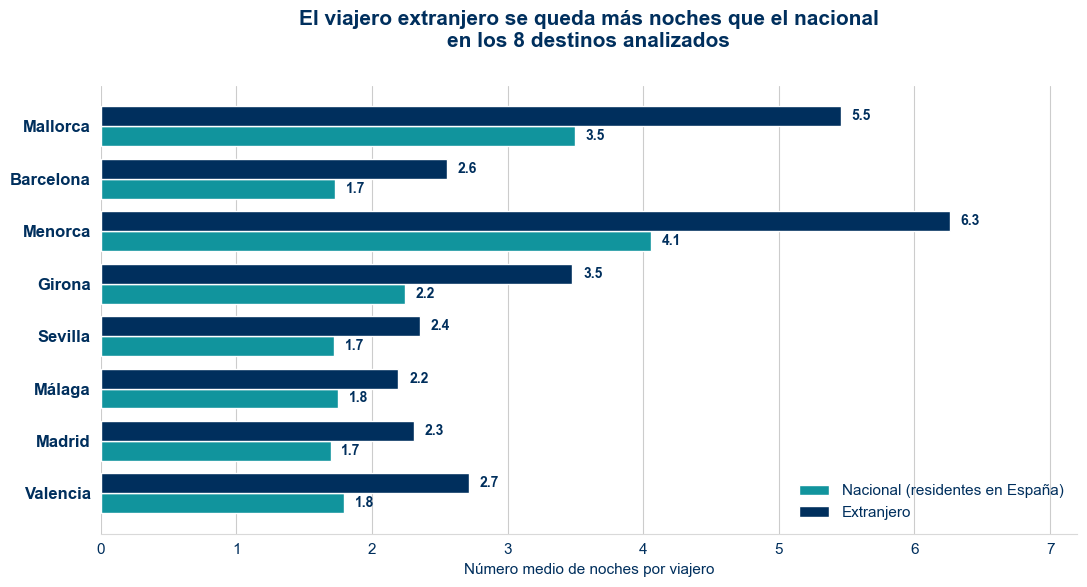

In [57]:
# Gráfico principal del bloque: estancia media por mercado y procedencia.
# Barras horizontales para que las etiquetas de los mercados se lean sin girar.
datos = resumen_mercados.loc[ORDEN_MERCADOS]
posiciones = range(len(datos))
altura = 0.38
fig, ax = plt.subplots(figsize=(11, 6))
barras_nac = ax.barh(
    [p + altura / 2 for p in posiciones],
    datos["Residentes en España"],
    height=altura,
    color=COLOR_NACIONAL,
    label=ETIQUETA_NACIONAL,
)
barras_ext = ax.barh(
    [p - altura / 2 for p in posiciones],
    datos["Residentes en el Extranjero"],
    height=altura,
    color=COLOR_EXTRANJERO,
    label=ETIQUETA_EXTRANJERO,
)
for barras in (barras_nac, barras_ext):
    for barra in barras:
        ancho = barra.get_width()
        ax.text(
            ancho + 0.08,
            barra.get_y() + barra.get_height() / 2,
            f"{ancho:.1f}",
            va="center",
            fontsize=10,
            fontweight="bold",
        )
ax.set_yticks(list(posiciones))
ax.set_yticklabels(datos.index, fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.set_xlabel("Número medio de noches por viajero")
# Solo valores enteros en el eje: los decimales ya están sobre las barras
ax.set_xticks(range(0, 8))
# Titulo que enuncia el hallazgo; el subtitulo recoge la unidad y el periodo
ax.set_title(
    "El viajero extranjero se queda más noches que el nacional\n"
    "en los 8 destinos analizados",
    fontsize=15,
    fontweight="bold",
    pad=28,
)
ax.set_xlim(0, datos["Residentes en el Extranjero"].max() * 1.15)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.1 Cobertura del dato en Menorca

Menorca no tiene los doce meses publicados: el INE aplica secreto estadístico cuando hay
menos de cuatro establecimientos abiertos con movimiento, algo habitual en destinos con
fuerte temporada. Su estancia media corresponde por tanto solo a los meses publicados,
concentrados en temporada alta, y no al año completo.

In [39]:
cobertura = (
    mercados[mercados["metrica"] == "pernoctaciones"]
    .pivot_table(
        index="mercado_stayspain",
        columns="mes",
        values="sin_dato",
        aggfunc="max",
    )
)

meses_sin_publicar = (
    cobertura
    .apply(lambda fila: sorted(fila[fila == 1].index.tolist()), axis=1)
    .rename("meses_sin_dato_publicado")
    .reindex(ORDEN_MERCADOS)
)

display(meses_sin_publicar.to_frame())

,meses_sin_dato_publicado
mercado_stayspain,
Mallorca,[]
Barcelona,[]
Menorca,"[1, 12]"
Girona,[]
Sevilla,[]
Málaga,[]
Madrid,[]
Valencia,[]


## 6. Zoom — estancia media según la comunidad autónoma de origen

Segundo nivel de lectura: dentro del viajero **nacional**, ¿cambia la estancia según la
comunidad autónoma de la que procede?

El destino sigue siendo el mercado; lo que se abre es el **origen**. La comunidad
autónoma aparece aquí exclusivamente como procedencia del viajero, nunca como destino.

### Cómo se obtiene esta cifra

La EOH no publica directamente la estancia media por origen. Se estima combinando dos
tablas:

- la tabla de **porcentajes de procedencia** por provincia de destino,
- y los **totales de viajeros y pernoctaciones nacionales** de esa misma provincia.

Para cada mes se aplica el porcentaje al total correspondiente, y solo **después de
sumar todos los meses** se calcula el cociente. Este orden es importante: promediar
cocientes mensuales daría el mismo peso a un mes de temporada alta que a uno de
temporada baja.

### Nivel geográfico de este apartado

Los porcentajes de procedencia se publican por **provincia**, no por punto o zona
turística. Por eso este zoom trabaja con la provincia asociada a cada mercado, y
**Mallorca y Menorca comparten un único origen agregado (Illes Balears)**: la fuente no
permite separarlas.

In [40]:
origen = df[
    (df["anio"] == ANIO_REFERENCIA)
    & (df["es_procedencia_nacional"])
].copy()

print("Tabla de origen:", ", ".join(sorted(origen["tabla"].unique())))
print("Nivel geográfico:", ", ".join(sorted(origen["nivel_geo"].unique())))
print("Provincias de destino:", ", ".join(sorted(origen["geo"].unique())))

Tabla de origen: 2069
Nivel geográfico: provincia
Provincias de destino: Balears, Illes, Barcelona, Girona, Madrid, Málaga, Sevilla, Valencia/València


In [41]:
# Se usa 'valor_estimado_origen' (porcentaje ya aplicado al total provincial),
# no 'valor', que es solo el porcentaje publicado por el INE.
estancia_origen = calcular_estancia_media(
    origen,
    ["mercados_relacionados", "categoria"],
    columna_valor="valor_estimado_origen",
)

estancia_origen["origen_corto"] = (
    estancia_origen["categoria"].map(acortar_nombre)
)

# Se descartan los grupos sin cociente calculable por falta de viajeros
estancia_origen = estancia_origen[estancia_origen["estancia_media"].notna()]

print(f"Combinaciones destino x origen: {len(estancia_origen):,}")

Combinaciones destino x origen: 133


### 6.1 Comparación con el origen de la propia región

La pregunta operativa es si el viajero que llega de más lejos permanece más noches que el
de la propia comunidad. Se comparan tres orígenes de referencia por mercado.

In [42]:
# Origen de la propia región de cada mercado, para medir el efecto proximidad
ORIGEN_PROPIO = {
    "Barcelona": "Cataluña",
    "Girona": "Cataluña",
    "Madrid": "Madrid, Comunidad de",
    "Valencia": "Comunitat Valenciana",
    "Málaga": "Andalucía",
    "Sevilla": "Andalucía",
    "Mallorca | Menorca": "Balears, Illes",
}

ORIGENES_COMPARADOS = [
    "Cataluña", "Madrid, Comunidad de",
    "Comunitat Valenciana", "Andalucía",
]

comparacion_origen = (
    estancia_origen[
        estancia_origen["categoria"].isin(
            ORIGENES_COMPARADOS + ["Balears, Illes"]
        )
    ]
    .pivot(
        index="mercados_relacionados",
        columns="origen_corto",
        values="estancia_media",
    )
)

display(comparacion_origen.round(2))

origen_corto,Andalucía,Balears,Cataluña,Comunitat Valenciana,Madrid
mercados_relacionados,,,,,
Barcelona,1.96,1.64,1.83,1.79,1.76
Girona,2.69,2.07,1.97,2.45,2.60
Madrid,1.84,1.81,1.73,1.69,2.00
Mallorca | Menorca,3.49,3.28,3.32,3.13,3.49
Málaga,2.03,2.70,2.53,2.30,2.88
Sevilla,1.57,1.94,1.94,1.98,1.81
Valencia,2.11,2.04,1.80,1.90,2.34


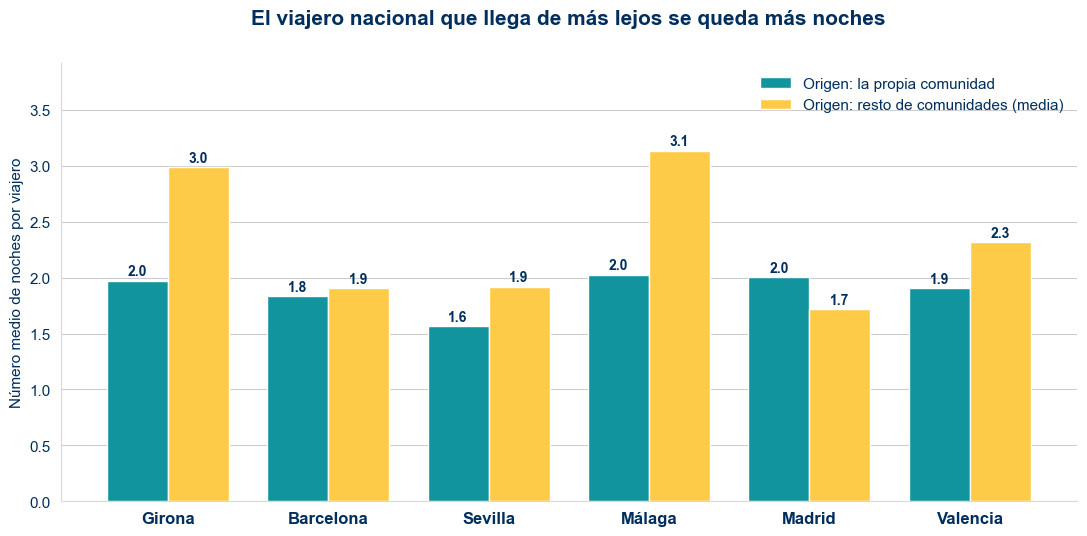

In [50]:
# Se representan los mercados con desglose de origen propio disponible.
# Mallorca y Menorca quedan fuera del gráfico: comparten el origen agregado
# 'Illes Balears' y no permiten distinguir el efecto proximidad por isla.
mercados_zoom = [
    "Girona", "Barcelona", "Sevilla",
    "Málaga", "Madrid", "Valencia",
]

datos_zoom = []
for mercado in mercados_zoom:
    fila = estancia_origen[estancia_origen["mercados_relacionados"] == mercado]
    propio = ORIGEN_PROPIO[mercado]

    valor_propio = fila.loc[
        fila["categoria"] == propio, "estancia_media"
    ]
    otros = fila[fila["categoria"] != propio]

    datos_zoom.append({
        "mercado": mercado,
        "propio": float(valor_propio.iloc[0]) if len(valor_propio) else None,
        "otros_media": float(otros["estancia_media"].mean()),
        "otros_max": float(otros["estancia_media"].max()),
    })

datos_zoom = pd.DataFrame(datos_zoom).set_index("mercado")

fig, ax = plt.subplots(figsize=(11, 5.5))
posiciones = range(len(datos_zoom))
ancho = 0.38

ax.bar(
    [p - ancho / 2 for p in posiciones],
    datos_zoom["propio"],
    width=ancho,
    color=COLOR_NACIONAL,
    label="Origen: la propia comunidad",
)
ax.bar(
    [p + ancho / 2 for p in posiciones],
    datos_zoom["otros_media"],
    width=ancho,
    color=COLOR_ACENTO,
    label="Origen: resto de comunidades (media)",
)

for posicion, (_, fila) in enumerate(datos_zoom.iterrows()):
    ax.text(posicion - ancho / 2, fila["propio"] + 0.05,
            f"{fila['propio']:.1f}", ha="center", fontsize=10,
            fontweight="bold")
    ax.text(posicion + ancho / 2, fila["otros_media"] + 0.05,
            f"{fila['otros_media']:.1f}", ha="center", fontsize=10,
            fontweight="bold")

ax.set_xticks(list(posiciones))
ax.set_xticklabels(datos_zoom.index, fontsize=12, fontweight="bold")
ax.set_ylabel("Número medio de noches por viajero")

ax.set_title(
    "El viajero nacional que llega de más lejos se queda más noches",
    fontsize=15,
    fontweight="bold",
    pad=28,
)

ax.set_ylim(0, datos_zoom["otros_media"].max() * 1.25)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

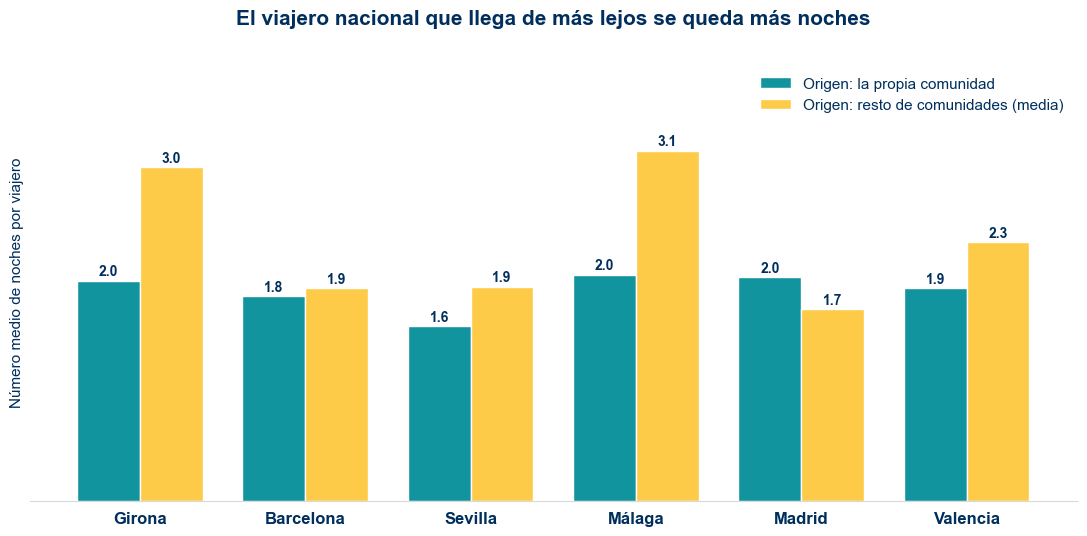

In [52]:
# Se representan los mercados con desglose de origen propio disponible.
# Mallorca y Menorca quedan fuera del gráfico: comparten el origen agregado
# 'Illes Balears' y no permiten distinguir el efecto proximidad por isla.
mercados_zoom = [
    "Girona", "Barcelona", "Sevilla",
    "Málaga", "Madrid", "Valencia",
]
datos_zoom = []
for mercado in mercados_zoom:
    fila = estancia_origen[estancia_origen["mercados_relacionados"] == mercado]
    propio = ORIGEN_PROPIO[mercado]
    valor_propio = fila.loc[
        fila["categoria"] == propio, "estancia_media"
    ]
    otros = fila[fila["categoria"] != propio]
    datos_zoom.append({
        "mercado": mercado,
        "propio": float(valor_propio.iloc[0]) if len(valor_propio) else None,
        "otros_media": float(otros["estancia_media"].mean()),
        "otros_max": float(otros["estancia_media"].max()),
    })
datos_zoom = pd.DataFrame(datos_zoom).set_index("mercado")
fig, ax = plt.subplots(figsize=(11, 5.5))
posiciones = range(len(datos_zoom))
ancho = 0.38
ax.bar(
    [p - ancho / 2 for p in posiciones],
    datos_zoom["propio"],
    width=ancho,
    color=COLOR_NACIONAL,
    label="Origen: la propia comunidad",
)
ax.bar(
    [p + ancho / 2 for p in posiciones],
    datos_zoom["otros_media"],
    width=ancho,
    color=COLOR_ACENTO,
    label="Origen: resto de comunidades (media)",
)
for posicion, (_, fila) in enumerate(datos_zoom.iterrows()):
    ax.text(posicion - ancho / 2, fila["propio"] + 0.05,
            f"{fila['propio']:.1f}", ha="center", fontsize=10,
            fontweight="bold")
    ax.text(posicion + ancho / 2, fila["otros_media"] + 0.05,
            f"{fila['otros_media']:.1f}", ha="center", fontsize=10,
            fontweight="bold")
ax.set_xticks(list(posiciones))
ax.set_xticklabels(datos_zoom.index, fontsize=12, fontweight="bold")
ax.set_ylabel("Número medio de noches por viajero")
# Los valores se leen sobre las barras: el eje vertical no aporta lectura
ax.set_yticks([])                                              # <--
ax.set_title(
    "El viajero nacional que llega de más lejos se queda más noches",
    fontsize=15,
    fontweight="bold",
    pad=28,
)
ax.set_ylim(0, datos_zoom["otros_media"].max() * 1.25)
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=False)                               # <--
ax.spines[["top", "right", "left"]].set_visible(False)         # <--
plt.tight_layout()
plt.show()

### 6.2 Detalle por origen de los mercados con mayor contraste

Se muestran los orígenes concretos de los mercados donde la diferencia entre proximidad y
distancia es más visible.

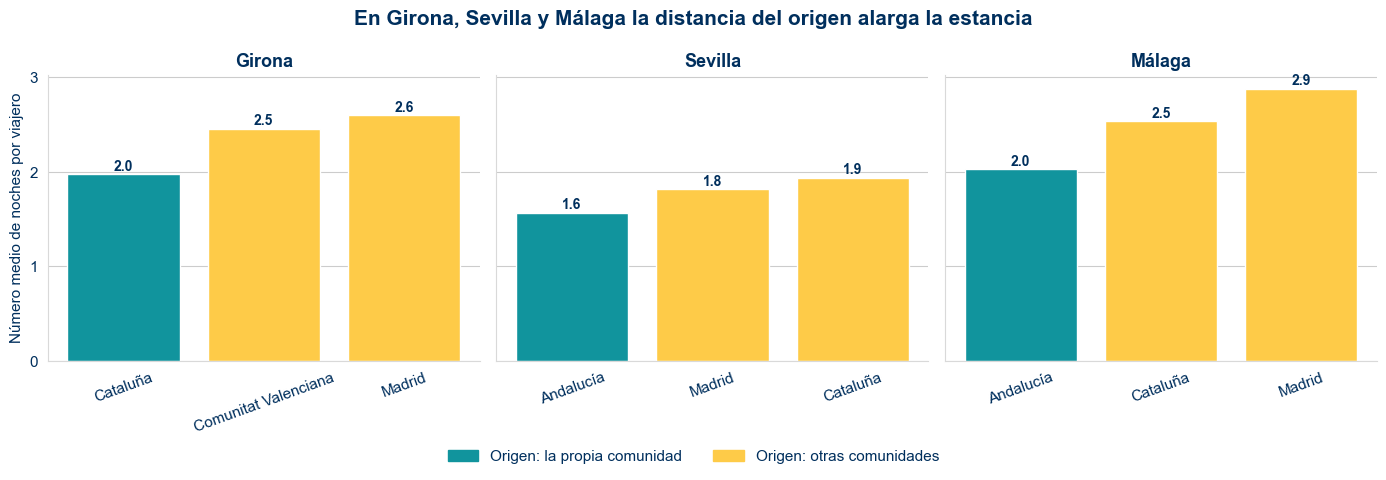

In [56]:
DETALLE = {
    "Girona": ["Cataluña", "Comunitat Valenciana", "Madrid, Comunidad de"],
    "Sevilla": ["Andalucía", "Madrid, Comunidad de", "Cataluña"],
    "Málaga": ["Andalucía", "Cataluña", "Madrid, Comunidad de"],
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, (mercado, origenes) in zip(axes, DETALLE.items()):
    fila = estancia_origen[
        (estancia_origen["mercados_relacionados"] == mercado)
        & (estancia_origen["categoria"].isin(origenes))
    ].set_index("categoria").reindex(origenes)
    # El primer origen de cada lista es la propia comunidad del mercado
    colores = [COLOR_NACIONAL] + [COLOR_ACENTO] * (len(origenes) - 1)
    barras = ax.bar(
        [acortar_nombre(o) for o in origenes],
        fila["estancia_media"],
        color=colores,
    )
    for barra in barras:
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.04,
            f"{barra.get_height():.1f}",
            ha="center",
            fontsize=10,
            fontweight="bold",
        )
    ax.set_title(mercado, fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", labelrotation=20)
    ax.grid(axis="x", visible=False)
    # Solo valores enteros en el eje: los decimales ya están sobre las barras
    ax.set_yticks(range(0, 4))
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Número medio de noches por viajero")
leyenda = [
    mpatches.Patch(color=COLOR_NACIONAL, label="Origen: la propia comunidad"),
    mpatches.Patch(color=COLOR_ACENTO, label="Origen: otras comunidades"),
]
fig.legend(handles=leyenda, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.suptitle(
    "En Girona, Sevilla y Málaga la distancia del origen alarga la estancia",
    fontsize=15,
    fontweight="bold",
)


plt.tight_layout()
plt.show()

## 7. Resumen de resultados

Tabla final con la medida principal por mercado, lista para su uso en el dashboard y en
la presentación.

In [45]:
resumen_final = (
    resumen_mercados
    .rename(columns={
        "Residentes en España": "estancia_media_nacional",
        "Residentes en el Extranjero": "estancia_media_extranjero",
    })[
        ["tipo_mercado", "estancia_media",
         "estancia_media_nacional", "estancia_media_extranjero",
         "diferencia", "pernoctaciones", "viajeros", "meses_publicados"]
    ]
    .round(2)
)

display(resumen_final)

,tipo_mercado,estancia_media,estancia_media_nacional,estancia_media_extranjero,diferencia,pernoctaciones,viajeros,meses_publicados
mercado_stayspain,,,,,,,,
Mallorca,Isla,5.27,3.49,5.46,1.96,49265920.0,9348518.0,12
Barcelona,Ciudad,2.41,1.73,2.55,0.82,21686712.0,8993914.0,12
Menorca,Isla,5.72,4.06,6.26,2.20,4798290.0,838978.0,10
Girona,Zona costera,3.01,2.24,3.48,1.24,12246036.0,4067698.0,12
Sevilla,Ciudad,2.12,1.72,2.35,0.64,6612695.0,3125669.0,12
Málaga,Ciudad,2.04,1.75,2.20,0.44,3730780.0,1832553.0,12
Madrid,Ciudad,2.06,1.69,2.31,0.62,21422510.0,10414317.0,12
Valencia,Ciudad,2.31,1.80,2.71,0.92,4929683.0,2132311.0,12


## 8. Conclusiones

Las cifras citadas corresponden a los resultados obtenidos en las celdas anteriores para
el año de referencia 2025.

**Estancia media por destino**

- Los mercados insulares y la zona turística de Girona presentan estancias claramente
  superiores a las de las ciudades.
- Las cinco ciudades se mueven en un rango estrecho, propio de un patrón de estancia
  corta de tipo urbano.
- Menorca no tiene los doce meses publicados, por lo que su estancia media corresponde
  únicamente a los meses con dato disponible, concentrados en temporada alta. Es un valor
  representativo de esos meses, no del año completo.

**Procedencia nacional frente a extranjera**

- El viajero extranjero permanece más noches que el residente en España en **todos** los
  mercados analizados, sin excepción.
- La diferencia es mayor en los destinos insulares y menor en las ciudades, coherente con
  el mayor coste de desplazamiento del viaje internacional a las islas.

**Zoom sobre el origen del viajero nacional**

- En Girona, Sevilla y Málaga el viajero nacional procedente de otras comunidades
  permanece más noches que el de la propia comunidad: en esos destinos, la distancia del
  origen se asocia a estancias más largas.
- En Barcelona y Madrid la estancia apenas varía según el origen: el patrón de visita
  corta se mantiene venga de donde venga el viajero.
- Esta lectura solo es posible para los mercados con desglose provincial propio. Mallorca
  y Menorca comparten el origen agregado de Illes Balears y no pueden separarse.

**Limitaciones que acompañan a estas conclusiones**

- La EOH mide establecimientos hoteleros y no apartamentos turísticos, por lo que estos
  valores funcionan como referencia oficial del comportamiento de la demanda, no como
  medida directa de la plataforma.
- Las tablas utilizadas no incluyen la categoría o el tipo de establecimiento, de modo que
  no es posible separar los resultados por tipología de alojamiento.
- Los datos desde junio de 2025 son provisionales.
- La estancia media por origen es una estimación ponderada a partir de porcentajes
  publicados, no un dato directo, y se calcula a nivel provincial.
- Los mercados no comparten nivel geográfico: las ciudades son municipios y Girona,
  Mallorca y Menorca son zonas turísticas. Las comparaciones entre ellos deben leerse
  teniendo presente esa diferencia.
- La fuente no recoge el motivo del viaje, por lo que las diferencias observadas se
  describen como patrones y no como explicaciones causales.